
<div align="center">

  #  **EJERCICIOS AUTOENCODERS**

  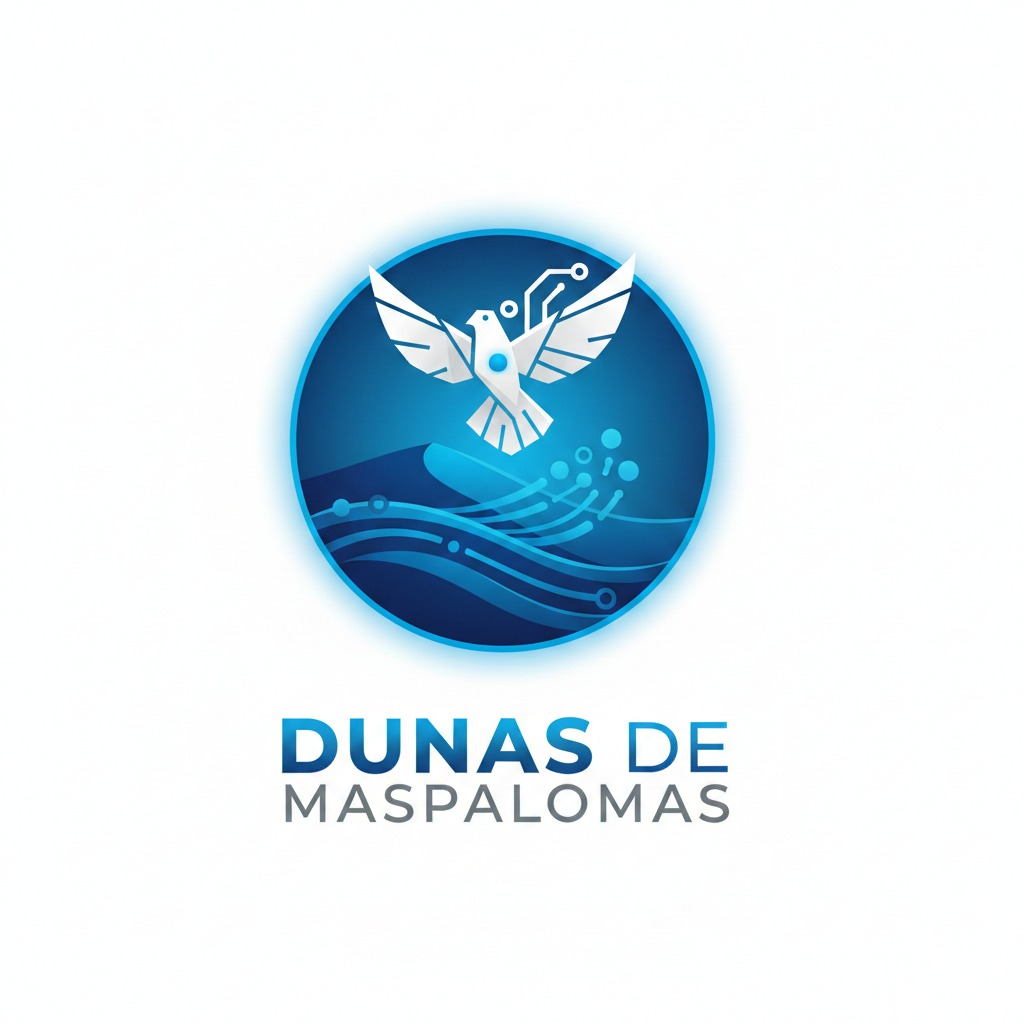
</div>

***EJERCICIO 1***

Construir y entrenar un AE para reconstruir imágenes del dataset MNIST utilizando PyTorch. Para ello, seguir los pasos que se indican a continuación:
Carga y preprocesado de datos: Cargar el dataset MNIST, normalizar los valores de los píxeles al rango $[0,1]$ y aplanar las imágenes de $28 \times 28$ píxeles en vectores de dimensión $784$.

Definición de la arquitectura del AE: Implementar una red neuronal AE con la siguiente estructura:
*   Codificador: 784 → 128 → 16
*   Decodificador: 16 → 128 → 784

con activación sigmoide final para producir salidas entre $0$ y $1$.


Función de pérdida: Combinar entropía cruzada.

Entrenamiento: Entrenar la red durante $20$ épocas usando descenso del gradiente
estocástico.

Visualización: Mostrar por pantalla un ejemplo de reconstrucción de cada uno de los
diez dígitos junto con las imágenes originales.

Tras varias pruebas, se ha optado por cambiar el método de entrenamiento del gradiente estocástico por un métdodo Adams, lo que permite obtener resultados mucho más precisos con un número menor de épocas. Además se ha añadido un archivo GIF que permite visualizar el paso de la imagen original a la reconstruida mediante una transformación lineal.





Iniciando el entrenamiento...
Época [1/15], Pérdida: 0.1319
Época [2/15], Pérdida: 0.1080
Época [3/15], Pérdida: 0.1057
Época [4/15], Pérdida: 0.1045
Época [5/15], Pérdida: 0.1038
Época [6/15], Pérdida: 0.1033
Época [7/15], Pérdida: 0.1031
Época [8/15], Pérdida: 0.1026
Época [9/15], Pérdida: 0.1026
Época [10/15], Pérdida: 0.1022
Época [11/15], Pérdida: 0.1020
Época [12/15], Pérdida: 0.1019
Época [13/15], Pérdida: 0.1018
Época [14/15], Pérdida: 0.1016
Época [15/15], Pérdida: 0.1015


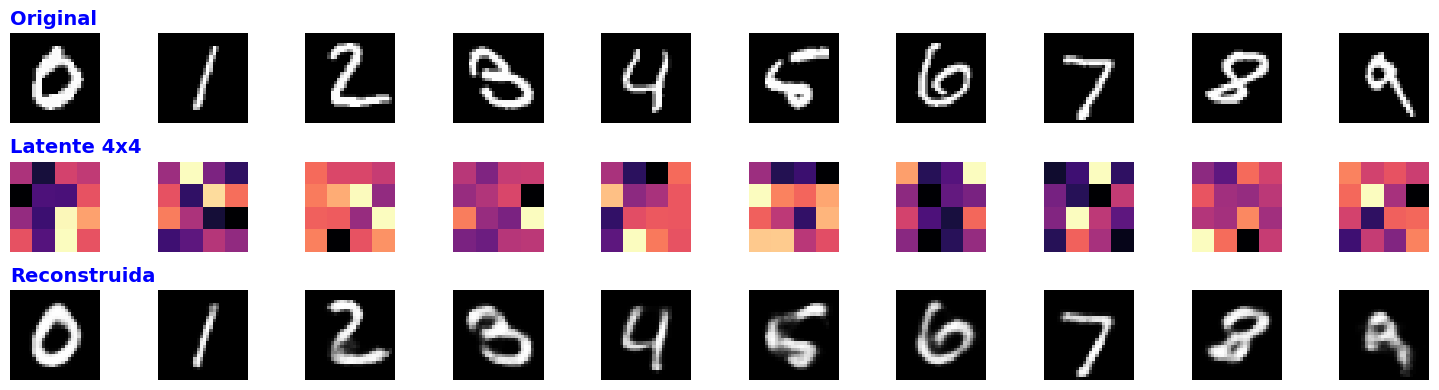

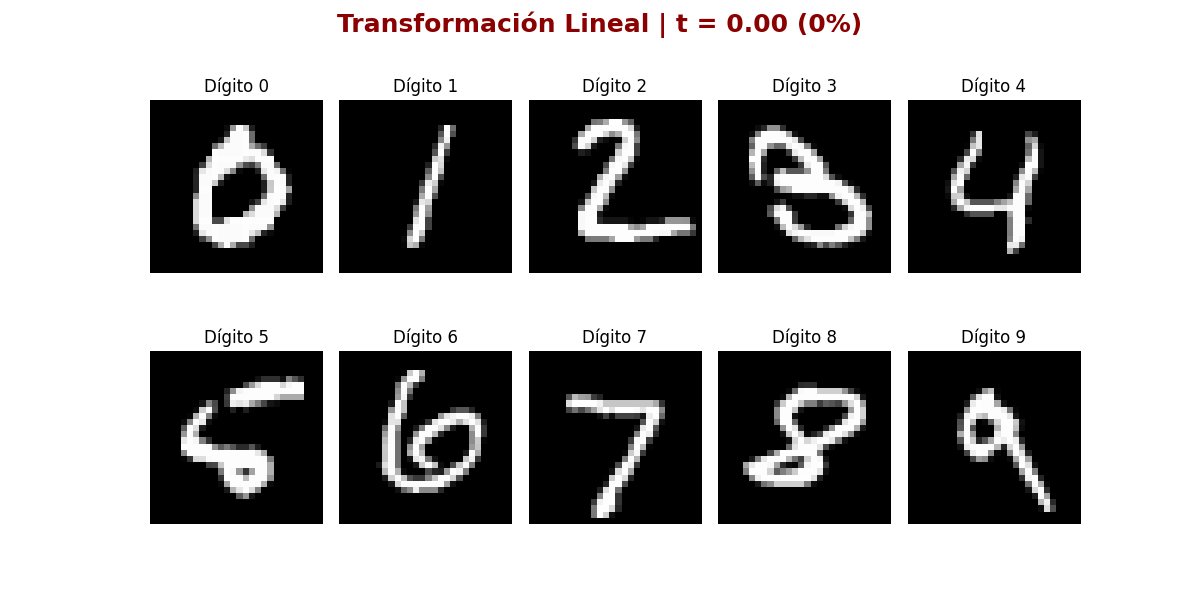

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from torch.utils.data import DataLoader
from PIL import Image
import numpy as np
from IPython.display import Image as DisplayImage, display

# 1. CARGA Y PREPROCESADO DE DATOS
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: torch.flatten(x))
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=1, shuffle=False)

# 2. ARQUITECTURA DEL AE
class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(784, 128),
            nn.ReLU(),
            nn.Linear(128, 16)
        )
        self.decoder = nn.Sequential(
            nn.Linear(16, 128),
            nn.ReLU(),
            nn.Linear(128, 784),
            nn.Sigmoid()
        )
    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

model = Autoencoder()

# 3. PÉRDIDA Y OPTIMIZACIÓN
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# 4. ENTRENAMIENTO
epocas = 15
print("Iniciando el entrenamiento...")
for epoch in range(epocas):
    train_loss = 0.0
    for images, _ in train_loader:
        outputs = model(images)
        loss = criterion(outputs, images)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)

    train_loss = train_loss / len(train_loader.dataset)
    print(f'Época [{epoch+1}/{epocas}], Pérdida: {train_loss:.4f}')


# 5. VISUALIZACIÓN DE RESULTADOS (Estática)
model.eval()
ejemplos_digitos = {}

for images, labels in test_loader:
    label = labels.item()
    if label not in ejemplos_digitos:
        ejemplos_digitos[label] = images
    if len(ejemplos_digitos) == 10:
        break

imagenes_originales = [ejemplos_digitos[i] for i in range(10)]
imagenes_originales_tensor = torch.cat(imagenes_originales)

with torch.no_grad():
    codificaciones = model.encoder(imagenes_originales_tensor)
    reconstrucciones = model.decoder(codificaciones)

# Mostramos las imágenes originales y las reconstruidas estáticas
fig, axes = plt.subplots(nrows=3, ncols=10, figsize=(15, 4))

for i in range(10):
    ax = axes[0, i]
    ax.imshow(imagenes_originales_tensor[i].view(28, 28).numpy(), cmap='gray')
    if i == 0:
        ax.set_title('Original', color='blue', fontsize=14, fontweight='bold', loc='left')
    ax.axis('off')

    ax = axes[1, i]
    latente_4x4 = codificaciones[i].view(4, 4).numpy()
    ax.imshow(latente_4x4, cmap='magma')
    if i == 0:
        ax.set_title('Latente 4x4', color='blue', fontsize=14, fontweight='bold', loc='left')
    ax.axis('off')

    ax = axes[2, i]
    ax.imshow(reconstrucciones[i].view(28, 28).numpy(), cmap='gray')
    if i == 0:
        ax.set_title('Reconstruida', color='blue', fontsize=14, fontweight='bold', loc='left')
    ax.axis('off')

plt.tight_layout()
plt.show()


# 6. GENERACIÓN DEL GIF
import matplotlib.animation as animation

t_originales=imagenes_originales_tensor.cpu().detach()
t_reconstruidas=reconstrucciones.cpu().detach()

frames_pausa_inicio=10
frames_transicion=40
frames_pausa_fin=50  # Pausa larga al final
total_frames=frames_pausa_inicio + frames_transicion + frames_pausa_fin

fig, axes_grid=plt.subplots(nrows=2, ncols=5, figsize=(12, 6))
axes=axes_grid.flatten()
plt.subplots_adjust(wspace=0.1, hspace=0.3, top=0.85)
plots_imagenes=[]

# Inicializamos las imágenes
for i in range(10):
    img_obj=axes[i].imshow(t_originales[i].view(28, 28).numpy(), cmap='gray', vmin=0, vmax=1)
    axes[i].set_title(f"Dígito {i}")
    axes[i].axis('off')
    plots_imagenes.append(img_obj)

# Esta función se ejecuta en cada uno de los frames
def update_animation(frame_idx):
    # 1. Calcular 't'
    if frame_idx < frames_pausa_inicio:
        t=0.0
    elif frame_idx < frames_pausa_inicio + frames_transicion:
        step_actual=frame_idx - frames_pausa_inicio
        t=step_actual / (frames_transicion - 1)
    else:
        t=1.0

    # ACTUALIZACIÓN DEL TÍTULO EN CADA FRAME
    porcentaje = int(t * 100)
    fig.suptitle(f'Transformación Lineal | t = {t:.2f} ({porcentaje}%)',
                 fontsize=18, fontweight='bold', color='darkred')

    # 2. Aplicar interpolación a las imágenes
    for i in range(10):
        img_orig=t_originales[i].view(28, 28)
        img_recon=t_reconstruidas[i].view(28, 28)

        # Ecuación lineal: (1 - t)*A + t*B
        img_interpolada=(1 - t) * img_orig + t * img_recon
        plots_imagenes[i].set_data(img_interpolada.numpy())
    return plots_imagenes
ani=animation.FuncAnimation(
    fig,
    update_animation,
    frames=total_frames,
    interval=50,
    blit=False # <-- IMPORTANTE: blit=False asegura que el título cambie en el GIF
)

nombre_archivo = 'morphing_mnist.gif'
ani.save(nombre_archivo, writer='pillow', fps=25)
display(DisplayImage(filename='morphing_mnist.gif'))
plt.close(fig)

***EJERCICIO 2***

Modificar el AE anterior para que el espacio latente tenga dimensión $2$ en lugar de $16$, es decir que comprima de la siguiente forma (784 → 128 → 2) y de nuevo visualizar imágenes y reconstrucciones

Iniciando el entrenamiento (Dimensión Latente 2)...
Época [1/40], Pérdida: 0.5061
Época [2/40], Pérdida: 0.2718
Época [3/40], Pérdida: 0.2674
Época [4/40], Pérdida: 0.2652
Época [5/40], Pérdida: 0.2631
Época [6/40], Pérdida: 0.2600
Época [7/40], Pérdida: 0.2554
Época [8/40], Pérdida: 0.2510
Época [9/40], Pérdida: 0.2481
Época [10/40], Pérdida: 0.2462
Época [11/40], Pérdida: 0.2447
Época [12/40], Pérdida: 0.2435
Época [13/40], Pérdida: 0.2425
Época [14/40], Pérdida: 0.2416
Época [15/40], Pérdida: 0.2407
Época [16/40], Pérdida: 0.2400
Época [17/40], Pérdida: 0.2393
Época [18/40], Pérdida: 0.2386
Época [19/40], Pérdida: 0.2380
Época [20/40], Pérdida: 0.2374
Época [21/40], Pérdida: 0.2369
Época [22/40], Pérdida: 0.2364
Época [23/40], Pérdida: 0.2359
Época [24/40], Pérdida: 0.2355
Época [25/40], Pérdida: 0.2350
Época [26/40], Pérdida: 0.2346
Época [27/40], Pérdida: 0.2342
Época [28/40], Pérdida: 0.2338
Época [29/40], Pérdida: 0.2335
Época [30/40], Pérdida: 0.2331
Época [31/40], Pérdida: 0.2

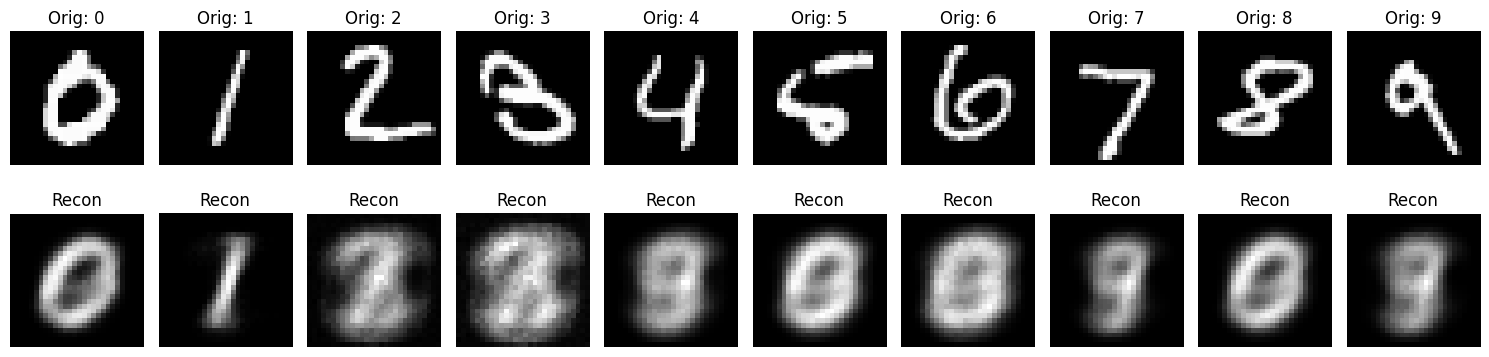

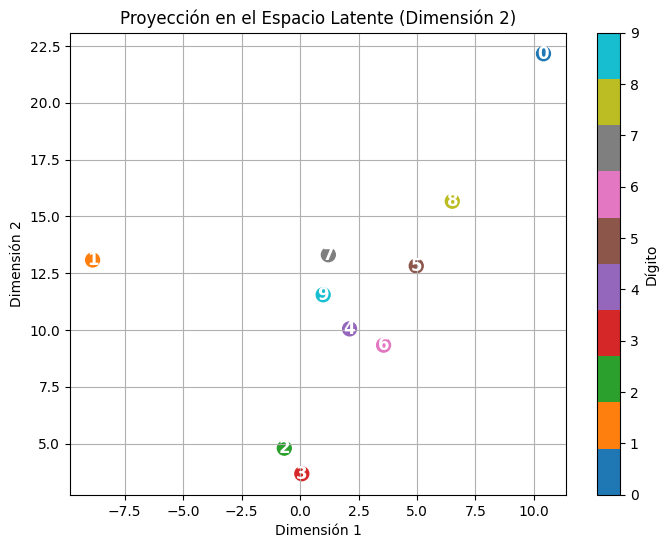

Creando animación GIF...

¡GIF generado exitosamente! Guardado como 'morphing_mnist_2.gif'


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# 1. CARGA Y PREPROCESADO DE DATOS (Se mantiene igual)
# Convertimos a tensor (normaliza los píxeles al rango [0,1]) y aplanamos a dimensión 784
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: torch.flatten(x))
])

# Descargamos y cargamos el dataset MNIST
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Usamos DataLoader para procesar en lotes durante el entrenamiento
train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=1, shuffle=False)

# 2. ARQUITECTURA DEL AE (CAMBIO A DIMENSIÓN 2)
class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()
        # Codificador: 784 → 128 → 2 (ANTES ERA 16)
        self.encoder = nn.Sequential(
            nn.Linear(784, 128),
            nn.ReLU(),
            nn.Linear(128, 2) # <-- CAMBIO A 2
        )
        # Decodificador: 2 → 128 → 784 (ANTES ERA 16)
        self.decoder = nn.Sequential(
            nn.Linear(2, 128), # <-- CAMBIO A 2
            nn.ReLU(),
            nn.Linear(128, 784),
            nn.Sigmoid() # Activación sigmoide final para salidas entre 0 y 1
        )
    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

model = Autoencoder()

# 3. PÉRDIDA Y OPTIMIZACIÓN
# Entropía cruzada binaria (BCE) ya que las entradas están normalizadas entre 0 y 1
criterion = nn.BCELoss()

# Descenso del gradiente estocástico (SGD) con una tasa de aprendizaje 0.1
# NOTA: Al comprimir tanto (a 2D), a SGD le cuesta mucho más converger.
# Si el resultado es muy malo, puedes subir el lr a 0.5 o usar optim.Adam(model.parameters(), lr=0.01)
optimizer = optim.SGD(model.parameters(), lr=0.05)

# 4. ENTRENAMIENTO
epocas = 40
print("Iniciando el entrenamiento (Dimensión Latente 2)...")
for epoch in range(epocas):
    train_loss = 0.0
    for images, _ in train_loader:
        # Forward pass (pasar las imágenes por el AE)
        outputs = model(images)
        loss = criterion(outputs, images) # Comparar salida con la imagen original

        # Backward pass y optimización
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)

    train_loss = train_loss / len(train_loader.dataset)
    print(f'Época [{epoch+1}/{epocas}], Pérdida: {train_loss:.4f}')


# 5. VISUALIZACIÓN DE RESULTADOS (Adaptada a 2D)
model.eval()
ejemplos_digitos = {}

# Recogemos un ejemplo de cada dígito
for images, labels in test_loader:
    label = labels.item()
    if label not in ejemplos_digitos:
        ejemplos_digitos[label] = images
    if len(ejemplos_digitos) == 10:
        break

# Ordenamos los dígitos del 0 al 9
imagenes_originales = [ejemplos_digitos[i] for i in range(10)]
imagenes_originales_tensor = torch.cat(imagenes_originales)

# Generamos las codificaciones (espacio latente) y las reconstrucciones
with torch.no_grad():
    # 1. Pasamos la imagen solo por el codificador para obtener el vector de tamaño 2
    codificaciones = model.encoder(imagenes_originales_tensor)
    # 2. Pasamos esa codificación por el decodificador para la imagen final
    reconstrucciones = model.decoder(codificaciones)

# Mostramos las imágenes originales y las reconstruidas
fig, axes = plt.subplots(nrows=2, ncols=10, figsize=(15, 4)) # Ahora solo 2 filas
for i in range(10):
    # Imágenes originales
    ax = axes[0, i]
    ax.imshow(imagenes_originales_tensor[i].view(28, 28).numpy(), cmap='gray')
    ax.set_title(f'Orig: {i}')
    ax.axis('off')

    # Reconstrucciones
    ax = axes[1, i]
    ax.imshow(reconstrucciones[i].view(28, 28).numpy(), cmap='gray')
    ax.set_title('Recon')
    ax.axis('off')

plt.tight_layout()
plt.show()

# EXTRA: VISUALIZACIÓN DEL ESPACIO LATENTE 2D
# Como ahora la codificación es un punto (x, y), podemos graficar dónde cae cada número
plt.figure(figsize=(8, 6))
coord_x = codificaciones[:, 0].numpy()
coord_y = codificaciones[:, 1].numpy()

plt.scatter(coord_x, coord_y, c=range(10), cmap='tab10', s=100)
for i in range(10):
    plt.annotate(str(i), (coord_x[i], coord_y[i]), fontsize=12, fontweight='bold', ha='center', va='center', color='white')

plt.title("Proyección en el Espacio Latente (Dimensión 2)")
plt.xlabel("Dimensión 1")
plt.ylabel("Dimensión 2")
plt.colorbar(ticks=range(10), label="Dígito")
plt.grid(True)
plt.show()

# --- 6. GENERACIÓN DEL GIF (T y PORCENTAJE EN CADA FRAME) ---
import matplotlib.animation as animation
print("Creando animación GIF...")

t_originales = imagenes_originales_tensor.cpu().detach()
t_reconstruidas = reconstrucciones.cpu().detach()

frames_pausa_inicio = 10
frames_transicion = 40
frames_pausa_fin = 50  # Pausa larga al final
total_frames = frames_pausa_inicio + frames_transicion + frames_pausa_fin

fig, axes_grid = plt.subplots(nrows=2, ncols=5, figsize=(12, 6))
axes = axes_grid.flatten()
plt.subplots_adjust(wspace=0.1, hspace=0.3, top=0.85) # Margen superior para el título

plots_imagenes = []

# Inicializamos las imágenes
for i in range(10):
    img_obj = axes[i].imshow(t_originales[i].view(28, 28).numpy(), cmap='gray', vmin=0, vmax=1)
    axes[i].set_title(f"Dígito {i}")
    axes[i].axis('off')
    plots_imagenes.append(img_obj)

# Esta función se ejecuta en cada uno de los frames
def update_animation(frame_idx):
    # 1. Calcular 't'
    if frame_idx < frames_pausa_inicio:
        t = 0.0
    elif frame_idx < frames_pausa_inicio + frames_transicion:
        step_actual = frame_idx - frames_pausa_inicio
        t = step_actual / (frames_transicion - 1)
    else:
        t = 1.0

    # --- ACTUALIZACIÓN DEL TÍTULO EN CADA FRAME ---
    porcentaje = int(t * 100)
    fig.suptitle(f'Transformación Lineal | t = {t:.2f} ({porcentaje}%)',
                 fontsize=18, fontweight='bold', color='darkred')

    # 2. Aplicar interpolación a las imágenes
    for i in range(10):
        img_orig = t_originales[i].view(28, 28)
        img_recon = t_reconstruidas[i].view(28, 28)

        # Ecuación lineal: (1 - t)*A + t*B
        img_interpolada = (1 - t) * img_orig + t * img_recon
        plots_imagenes[i].set_data(img_interpolada.numpy())

    return plots_imagenes

ani = animation.FuncAnimation(
    fig,
    update_animation,
    frames=total_frames,
    interval=50,
    blit=False # <-- IMPORTANTE: blit=False asegura que el título cambie en el GIF
)

nombre_archivo = 'morphing_mnist_2.gif'
ani.save(nombre_archivo, writer='pillow', fps=25)

print(f"\n¡GIF generado exitosamente! Guardado como '{nombre_archivo}'")
plt.close(fig)


***EJERCICIO 3***

Construir y entrenar un AE para reconstruir imágenes del dataset KMNIST utilizando PyTorch.

Para ello, seguir los pasos que se indican a continuación:

*   Carga y preprocesado de datos: Descargar y preparar el dataset KMNIST (Kuzushiji-MNIST), una alternativa al clásico MNIST que contiene imágenes de
caracteres manuscritos del alfabeto japonés hiragana, tomadas de textos
antiguos. El dataset incluye 10 clases distintas, correspondientes a 10 caracteres japoneses, y las imágenes tienen tamaño 28×28 píxeles en escala de grises, como en MNIST. Normalizar los valores de los píxeles al rango [0,1] y aplanar cada imagen en un vector de dimensión 784.
*    Definición de la arquitectura del AE: Implementar una red neuronal AE con la siguiente estructura: Codificador: 784 → 128 → 16, Decodificador: 16 → 128 → 784. Utilizar una función de activación sigmoide al final del decodificador para asegurar salidas en el intervalo [0,1].
*    Función de pérdida: Usar entropía cruzada binaria para medir la discrepancia entre la imagen original y la reconstruida.
*    Entrenamiento: Entrenar la red durante 20 épocas utilizando descenso del gradiente estocástico (SGD o Adam).
*    Visualización: Seleccionar un subconjunto del conjunto de test que incluya al menos un ejemplo de cada uno de los 10 caracteres distintos del dataset KMNIST. Mostrar las imágenes originales junto con sus reconstrucciones generadas por el AE, permitiendo comparar visualmente la calidad de la reconstrucción. Mostrar también una representación de vector del espacio latente de cada una de las figuras reconstruidas en forma de imagen de tamaño 4 por 4.
*    Si no se produce una buena reconstrucción, proponer alternativas para mejorarla.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# 1. Configuración y carga de datos (FashionMNIST)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: torch.flatten(x))
])

print("Descargando/Cargando dataset FashionMNIST...")
train_dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# 2. Arquitectura del Autoencoder
class AutoencoderFashion(nn.Module):
    def __init__(self):
        super(AutoencoderFashion, self).__init__()
        # Codificador: 784 -> 128 -> 16
        # Sin activación final para que el espacio latente abarque todo el espacio vectorial real
        self.encoder = nn.Sequential(
            nn.Linear(784, 128),
            nn.ReLU(),
            nn.Linear(128, 16)
        )
        # Decodificador: 16 -> 128 -> 784
        self.decoder = nn.Sequential(
            nn.Linear(16, 128),
            nn.ReLU(),
            nn.Linear(128, 784),
            nn.Sigmoid() # Salida [0,1]
        )

    def forward(self, x):
        z = self.encoder(x)
        recon = self.decoder(z)
        return recon, z

model = AutoencoderFashion().to(device)

# 3. Función de pérdida y optimizador
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 4. Entrenamiento (20 épocas)
epochs = 20
print(f"Iniciando entrenamiento en {device}...")

for epoch in range(epochs):
    train_loss = 0.0
    for data, _ in train_loader:
        data = data.to(device)

        # Forward
        recon, _ = model(data)
        loss = criterion(recon, data)

        # Backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * data.size(0)

    train_loss = train_loss / len(train_loader.dataset)
    print(f"Época [{epoch+1}/{epochs}] - Pérdida: {train_loss:.4f}")

# 5. Visualización
model.eval()
ejemplos = {}

# APAGAMOS LAS DERIVADAS PARA TODO EL PROCESO (Extracción + Inferencia + Dibujo)
with torch.no_grad():

    # 1. Extraemos un ejemplo de cada clase
    for data, targets in test_loader:
        for i in range(len(targets)):
            label = targets[i].item()
            if label not in ejemplos and len(ejemplos) < 10:
                ejemplos[label] = data[i].to(device)
        if len(ejemplos) == 10: break

    # 2. Dibujamos las 3 filas (¡Ahora sí, de forma segura!)
    fig, axes = plt.subplots(3, 10, figsize=(15, 6))

    for i in range(10):
        img_plana = ejemplos[i]
        recon_plana, latent = model(img_plana.unsqueeze(0))

        # Original
        axes[0, i].imshow(img_plana.cpu().view(28, 28).numpy(), cmap='gray')
        axes[0, i].axis('off')

        # Espacio Latente (16 valores reformateados a matriz de 4x4)
        axes[1, i].imshow(latent.cpu().view(4, 4).numpy(), cmap='magma')
        axes[1, i].axis('off')

        # Reconstruida
        axes[2, i].imshow(recon_plana.cpu().view(28, 28).numpy(), cmap='gray')
        axes[2, i].axis('off')

    axes[0, 0].set_title("Original", loc='left', color='blue', fontweight='bold')
    axes[1, 0].set_title("Latente 4x4", loc='left', color='blue', fontweight='bold')
    axes[2, 0].set_title("Reconstruida", loc='left', color='blue', fontweight='bold')
    plt.tight_layout()
    plt.show()

***TRANSICIÓN DEL ESPACIO LATENTE***

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from PIL import Image
import numpy as np
from IPython.display import Image as DisplayImage, display

# 1. Datos MNIST
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
transform=transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: torch.flatten(x))
])

train_dataset=datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset=datasets.MNIST(root='./data', train=False, download=True, transform=transform)
train_loader=DataLoader(train_dataset, batch_size=128, shuffle=True)

# 2. Modelo (AE Clásico)
class AutoencoderNumeros(nn.Module):
    def __init__(self):
        super(AutoencoderNumeros, self).__init__()
        self.encoder=nn.Sequential(nn.Linear(784, 128), nn.ReLU(), nn.Linear(128, 16))
        self.decoder=nn.Sequential(nn.Linear(16, 128), nn.ReLU(), nn.Linear(128, 784), nn.Sigmoid())

    def forward(self, x):
        z=self.encoder(x)
        recon=self.decoder(z)
        return recon, z

model=AutoencoderNumeros().to(device)

# 3. Entrenamiento de 15 épocas
epocas=15
print(f"Entrenando la red durante {epocas} épocas")
criterion=nn.BCELoss()
optimizer=optim.Adam(model.parameters(), lr=0.01)

for epoch in range(epocas):
    for data, _ in train_loader:
        data=data.to(device)
        recon, _=model(data)
        loss=criterion(recon, data)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    print(f"Época {epoch+1}/{epocas} completada.")

# 4. Selección de los números
img_7, img_9=None, None
for data, target in test_dataset:
    label=target.item() if isinstance(target, torch.Tensor) else target
    if label==7 and img_7 is None:
        img_7=data
    elif label==9 and img_9 is None:
        img_9=data
    if img_7 is not None and img_9 is not None:
        break

img_7, img_9=img_7.to(device), img_9.to(device)

# 5. Interpolación lineal y GIF
print("\nCalculando trayectoria en el espacio latente y generando el GIF")
model.eval()
frames_gif=[]

# Aumentamos el número de pasos para una transición más lenta en el GIF
num_pasos=60
alphas=np.linspace(0, 1, num_pasos)

with torch.no_grad():
    _, v_7=model(img_7.view(1, 784))
    _, v_9=model(img_9.view(1, 784))

    for alpha in alphas:
        # Combinación lineal : v=(1-t)*_7 + t*v_9
        v_t=(1.0 - float(alpha))*v_7 + float(alpha)*v_9
        recon_t=model.decoder(v_t)
        # Formato de imagen
        img_numpy=recon_t.view(28, 28).cpu().numpy()
        img_uint8=(img_numpy * 255).astype(np.uint8)
        # Tamaño del GIF
        img_pil=Image.fromarray(img_uint8)
        img_pil_grande=img_pil.resize((280, 280), Image.NEAREST)
        frames_gif.append(img_pil_grande)

ruta_gif="transformacion79.gif"
frames_completos=frames_gif + frames_gif[::-1]

frames_completos[0].save(
    ruta_gif,
    save_all=True,
    append_images=frames_completos[1:],
    duration=100,
    loop=0
)

print("Transformación del 7 al 9")
display(DisplayImage(filename=ruta_gif))